## Step 1: Download files from GitHub

In [1]:
import requests

BASE_URL = "https://raw.githubusercontent.com/karimabdelmonem/automated-explainable-ai-system/main/data/processed/"

files = [
    "X_train.parquet",
    "X_test.parquet",
    "y_train.parquet",
    "y_test.parquet",
    "data_processed.parquet"
]

print("[*] Downloading data files...")
for file_name in files:
    url = BASE_URL + file_name
    print(f"Downloading {file_name}...")

    response = requests.get(url)

    if response.status_code == 200:
        with open(file_name, 'wb') as f:
            f.write(response.content)
    else:
        print(f"Failed to download {file_name}. Status code: {response.status_code}")

print("[✓] All files downloaded successfully!\n")

[*] Downloading data files...
[✓] All files downloaded successfully!



## Step 2: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, roc_curve, auc
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Step 3: Load Data

In [3]:
print("\n[*] Loading tabular data...")
X_train = pd.read_parquet('X_train.parquet')
X_test = pd.read_parquet('X_test.parquet')
y_train = pd.read_parquet('y_train.parquet').squeeze()
y_test = pd.read_parquet('y_test.parquet').squeeze()

print(f"Data shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")


[*] Loading tabular data...
Data shapes -> X_train: (382424, 27), X_test: (38172, 27)


## Step 4: Train Machine Learning Models

In [4]:
models = {
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='logloss'),
    "Random_Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
}

probabilities = {}
metrics_results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc_score = roc_auc_score(y_test, y_prob)

    metrics_results[name] = {"Accuracy": acc, "F1-Score": f1, "ROC-AUC": auc_score}
    probabilities[name] = y_prob

    # Save Pipeline
    joblib.dump(model, f"{name.lower()}_model.joblib")
    print(f"[✓] Saved: {name.lower()}_model.joblib")


--- Training LightGBM ---
[✓] Saved: lightgbm_model.joblib

--- Training XGBoost ---
[✓] Saved: xgboost_model.joblib

--- Training Random_Forest ---
[✓] Saved: random_forest_model.joblib


## Step 5: Train Deep Learning Tabular MLP

In [5]:
print("\n--- Training Deep Learning Tabular Model (MLP) ---")

def build_tabular_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

deep_model = build_tabular_model(input_dim=X_train.shape[1])

# Callbacks to monitor performance on validation and prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = deep_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1 # This explicitly tracks the epochs, accuracy, and loss
)

# Evaluate Deep Learning Model
deep_prob = deep_model.predict(X_test).ravel()
deep_pred = (deep_prob > 0.5).astype(int)

metrics_results["Tabular_DL"] = {
    "Accuracy": accuracy_score(y_test, deep_pred),
    "F1-Score": f1_score(y_test, deep_pred, average='weighted'),
    "ROC-AUC": roc_auc_score(y_test, deep_prob)
}
probabilities["Tabular_DL"] = deep_prob

# Save Deep Learning model
deep_model.save('tabular_dl_model.keras')
print("\n[✓] Saved tabular deep learning model as tabular_dl_model.keras")


--- Training Deep Learning Tabular Model (MLP) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8659 - loss: 0.3214 - val_accuracy: 0.9026 - val_loss: 0.1733 - learning_rate: 0.0010
Epoch 2/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8790 - loss: 0.2953 - val_accuracy: 0.9130 - val_loss: 0.1563 - learning_rate: 0.0010
Epoch 3/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8812 - loss: 0.2899 - val_accuracy: 0.9172 - val_loss: 0.1507 - learning_rate: 0.0010
Epoch 4/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8822 - loss: 0.2876 - val_accuracy: 0.9192 - val_loss: 0.1446 - learning_rate: 0.0010
Epoch 5/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8832 - loss: 0.2857 - val_accuracy: 0.9099 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 6/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8843 - loss: 0.2839 - val_accuracy: 0.9250 - val_loss: 0.1389 - learning_rate: 0.0010
Epoch 7/20
4781/4781 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8

## Step 6: Final Comparison Table

In [6]:
df_comparison = pd.DataFrame(metrics_results).T
print("\n--- Final Model Comparison ---")
print(df_comparison)


--- Final Model Comparison ---
               Accuracy  F1-Score   ROC-AUC
LightGBM       0.883894  0.848407  0.745305
XGBoost        0.882060  0.847973  0.741783
Random_Forest  0.807136  0.817078  0.694552
Tabular_DL     0.876218  0.848413  0.746898


## Step 7: Plot Combined ROC-AUC Curves

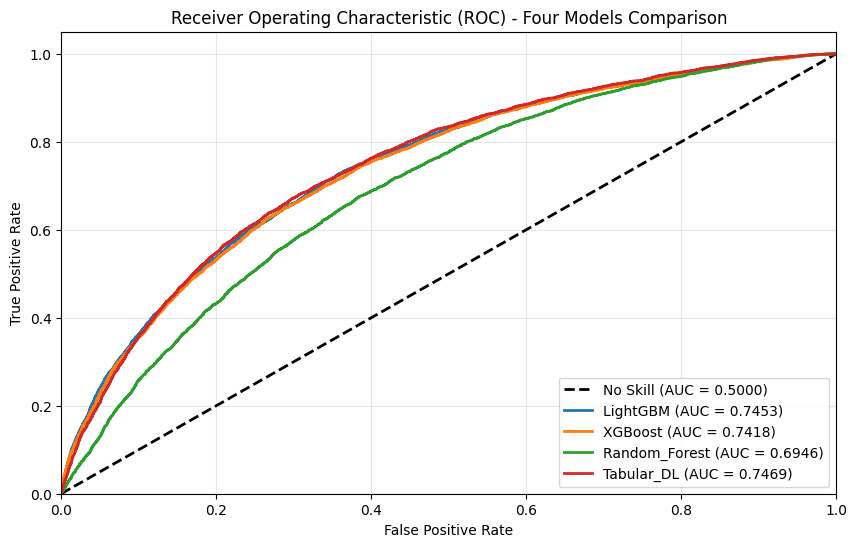


[✓] ROC curves generated and saved as models_roc_curves.png


In [7]:
plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='No Skill (AUC = 0.5000)')

for name, probs in probabilities.items():
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_val:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Four Models Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('models_roc_curves.png')
plt.show()
print("\n[✓] ROC curves generated and saved as models_roc_curves.png")